# ASSIGNMENT II: Machine Learning untuk Big Data
## Credit Default Prediction pada Platform P2P Lending

**Dataset:** Lending Club Loan Data (2007-2018)
**Problem:** Binary Classification - Prediksi risiko gagal bayar (`is_default`)
**Approach:** Perbandingan sklearn vs Spark MLlib

---

## TABLE OF CONTENTS
1. [Setup & Installation](#1-setup)
2. [Data Loading](#2-data-loading)
3. [Data Preprocessing](#3-preprocessing)
4. [Feature Engineering](#4-feature-engineering)
5. [Model Training (sklearn)](#5-model-sklearn)
6. [Model Training (Spark MLlib)](#6-model-spark)
7. [Evaluation & Comparison](#7-evaluation)
8. [Graph Analytics](#8-graph-analytics)
9. [Summary & Conclusions](#9-summary)

---
<a name="1-setup"></a>
## 1. SETUP & INSTALLATION

In [1]:
# Install required packages
!pip install -q pyspark xgboost graphframes shap

import os
import gc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("✅ Setup complete!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 10.5 MB/s eta 0:00:00
✅ Setup complete!


In [2]:
# Kaggle Authentication
kaggle_json_content = """
{
  "username": "danielwidhiarto",
  "key": "e33db3949bd9984c7f0c41f93f8cd39e"
}
"""

os.makedirs('/root/.kaggle', exist_ok=True)
with open('/root/.kaggle/kaggle.json', 'w') as f:
    f.write(kaggle_json_content)
os.chmod('/root/.kaggle/kaggle.json', 0o600)

print("✅ Kaggle authentication configured!")

✅ Kaggle authentication configured!


---
<a name="2-data-loading"></a>
## 2. DATA LOADING

In [3]:
# Download dataset from Kaggle
!kaggle datasets download -d wordsforthewise/lending-club -p /content/lending-club --unzip

!ls -lh /content/lending-club/

Dataset URL: https://www.kaggle.com/datasets/wordsforthewise/lending-club
License(s): CC0-1.0
100% 1.26G/1.26G [00:33<00:00, 40.6MB/s]

total 619M
drwxr-xr-x 2 root root 4.0K May 12 06:20 accepted_2007_to_2018q4.csv
-rw-r--r-- 1 root root 375M May 12 06:20 accepted_2007_to_2018Q4.csv.gz
drwxr-xr-x 2 root root 4.0K May 12 06:20 rejected_2007_to_2018q4.csv
-rw-r--r-- 1 root root 244M May 12 06:20 rejected_2007_to_2018Q4.csv.gz


In [4]:
# Define columns to use (26 columns from Assignment 1)
ACCEPTED_COLS = [
    'loan_amnt', 'funded_amnt', 'term', 'int_rate', 'installment',
    'grade', 'sub_grade', 'emp_length', 'home_ownership', 'annual_inc',
    'verification_status', 'issue_d', 'loan_status', 'purpose',
    'dti', 'fico_range_low', 'fico_range_high', 'delinq_2yrs',
    'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc',
    'addr_state', 'desc', 'application_type'
]

REJECTED_COLS = [
    'Amount Requested', 'Application Date', 'Loan Title', 'Risk_Score',
    'Debt-To-Income Ratio', 'Zip Code', 'State', 'Employment Length',
    'Policy Code'
]

print(f"Accepted columns: {len(ACCEPTED_COLS)}")
print(f"Rejected columns: {len(REJECTED_COLS)}")

Accepted columns: 26
Rejected columns: 9


In [5]:
# Load accepted loans data (direct - no chunking for Colab Pro)
print("Loading accepted loans data (direct load)...")

df_accepted = pd.read_csv(
    '/content/lending-club/accepted_2007_to_2018Q4.csv.gz',
    compression='gzip',
    low_memory=False
)

print(f"✅ Accepted loans loaded: {df_accepted.shape[0]:,} rows x {df_accepted.shape[1]} cols")
print(f"Memory usage: {df_accepted.memory_usage(deep=True).sum() / 1e9:.2f} GB")

Loading accepted loans data (direct load)...
✅ Accepted loans loaded: 2,260,701 rows x 151 cols
Memory usage: 6.28 GB


In [6]:
# NOTE: Rejected loans is only used for Graph Analytics (Section 8 - Bipartite Graph)
# For ML training, we ONLY use accepted loans (which has labeled data)
# If you want to skip Graph Analytics, you can comment out this section

# Load rejected loans data (for Graph Analytics ONLY)
print("Loading rejected loans data (for Graph Analytics only)...")

df_rejected = pd.read_csv(
    '/content/lending-club/rejected_2007_to_2018Q4.csv.gz',
    compression='gzip',
    low_memory=False
)

print(f"✅ Rejected loans loaded: {df_rejected.shape[0]:,} rows x {df_rejected.shape[1]} cols")
print(f"Memory usage: {df_rejected.memory_usage(deep=True).sum() / 1e9:.2f} GB")
print("⚠️  NOTE: Rejected loans is NOT used in ML training - only for Graph Analytics")

Loading rejected loans data (for Graph Analytics only)...
✅ Rejected loans loaded: 27,648,741 rows x 9 cols
Memory usage: 10.00 GB
⚠️  NOTE: Rejected loans is NOT used in ML training - only for Graph Analytics


In [7]:
# Quick look at the data
print("=" * 60)
print("ACCEPTED LOANS - First 5 rows")
print("=" * 60)
df_accepted.head()

ACCEPTED LOANS - First 5 rows


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,66310712,NaN,35000.0,35000.0,35000.0,60 months,14.85,829.90,C,C5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,68476807,NaN,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
# NOTE: Skipping df_rejected.head() display for ML section
# df_rejected is only used in Graph Analytics section
print("=" * 60)
print("REJECTED LOANS - Preview skipped for ML section")
print("(See Graph Analytics section for rejected loans analysis)")
print("=" * 60)
# df_rejected.head()  # Commented out - only used for Graph Analytics

REJECTED LOANS - Preview skipped for ML section
(See Graph Analytics section for rejected loans analysis)


---
<a name="3-preprocessing"></a>
## 3. DATA PREPROCESSING

In [9]:
def preprocess_accepted(df):
    """Preprocess accepted loans data"""
    df = df.copy()

    # Create target variable: is_default
    df['is_default'] = df['loan_status'].isin([
        'Charged Off',
        'Default',
        'Late (31-120 days)',
        'Late (16-30 days)'
    ]).astype(int)

    # Drop original loan_status (no longer needed)
    df.drop('loan_status', axis=1, inplace=True)

    # Convert term to numeric (e.g., '36 months' -> 36)
    df['term_months'] = df['term'].str.extract(r'(\d+)').astype(float)

    # Convert interest rate - handle both string and numeric
    if df['int_rate'].dtype == 'object':
        df['int_rate'] = df['int_rate'].str.replace('%', '').astype(float)

    # Convert revol_util - handle both string and numeric
    if df['revol_util'].dtype == 'object':
        df['revol_util'] = df['revol_util'].astype(str).str.replace('%', '')
        df['revol_util'] = pd.to_numeric(df['revol_util'], errors='coerce')

    # Extract year and month from issue_d
    df['issue_year']  = pd.to_datetime(df['issue_d'], format='%b-%Y').dt.year
    df['issue_month'] = pd.to_datetime(df['issue_d'], format='%b-%Y').dt.month

    # Convert emp_length to numeric
    emp_map = {
        '< 1 year': 0, '1 year': 1, '2 years': 2, '3 years': 3,
        '4 years': 4, '5 years': 5, '6 years': 6, '7 years': 7,
        '8 years': 8, '9 years': 9, '10+ years': 10
    }
    df['emp_length_num'] = df['emp_length'].map(emp_map)

    # Handle outliers for annual_inc (cap at 99th percentile)
    inc_cap = df['annual_inc'].quantile(0.99)
    df['annual_inc_clean'] = df['annual_inc'].clip(0, inc_cap)

    # Handle outliers for dti (clip to 0-100)
    df['dti_clean'] = df['dti'].clip(0, 100)

    # Handle outliers for revol_util (clip to 0-100)
    df['revol_util'] = df['revol_util'].clip(0, 100)

    return df

# Apply preprocessing
df_accepted = preprocess_accepted(df_accepted)
print(f"✅ Preprocessed accepted data: {df_accepted.shape}")
print(f"\nDefault rate: {df_accepted['is_default'].mean()*100:.2f}%")

✅ Preprocessed accepted data: (2260701, 157)

Default rate: 13.02%


In [10]:
# Check missing values
print("=" * 60)
print("MISSING VALUES SUMMARY")
print("=" * 60)

missing = df_accepted.isnull().sum()
missing_pct = (missing / len(df_accepted)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).sort_values('Missing %', ascending=False)

print(missing_df[missing_df['Missing Count'] > 0])

MISSING VALUES SUMMARY
                                            Missing Count   Missing %
member_id                                         2260701  100.000000
orig_projected_additional_accrued_interest        2252050   99.617331
hardship_end_date                                 2249784   99.517097
hardship_last_payment_amount                      2249784   99.517097
hardship_loan_status                              2249784   99.517097
...                                                   ...         ...
hardship_flag                                          33    0.001460
disbursement_method                                    33    0.001460
debt_settlement_flag                                   33    0.001460
issue_month                                            33    0.001460
issue_year                                             33    0.001460

[155 rows x 2 columns]


In [11]:
# Impute missing values
def impute_missing(df):
    """Impute missing values"""
    df = df.copy()

    # Numerical columns - impute with median
    numerical_cols = df.select_dtypes(include=[np.number]).columns
    for col in numerical_cols:
        if df[col].isnull().sum() > 0:
            df[col].fillna(df[col].median(), inplace=True)

    # Categorical columns - impute with 'Unknown'
    categorical_cols = df.select_dtypes(include=['object']).columns
    for col in categorical_cols:
        if df[col].isnull().sum() > 0:
            df[col].fillna('Unknown', inplace=True)

    return df

df_accepted = impute_missing(df_accepted)
print(f"✅ Missing values imputed")
print(f"Remaining missing values: {df_accepted.isnull().sum().sum()}")

✅ Missing values imputed
Remaining missing values: 2260701


---
<a name="4-feature-engineering"></a>
## 4. FEATURE ENGINEERING

In [12]:
def create_features(df):
    """Create derived features"""
    df = df.copy()

    # Average FICO score
    df['fico_avg'] = (df['fico_range_low'] + df['fico_range_high']) / 2

    # Credit utilization ratio (revol_bal / (revol_bal + 1))
    df['credit_utilization'] = (df['revol_bal'] / (df['revol_bal'] + 1)) * 100
    df['credit_utilization'] = df['credit_utilization'].clip(0, 100)

    # Loan to income ratio
    df['loan_to_income'] = df['loan_amnt'] / (df['annual_inc_clean'] + 1)

    # Installment to income ratio
    df['installment_to_income'] = df['installment'] / (df['annual_inc_clean'] / 12 + 1)

    # Total risk indicators
    df['total_risk_indicators'] = (
        df['pub_rec'].fillna(0) +
        df['delinq_2yrs'].fillna(0)
    )

    return df

df_accepted = create_features(df_accepted)
print(f"✅ Features created: {df_accepted.shape[1]} columns")

✅ Features created: 162 columns


In [13]:
# Define feature groups
TARGET = 'is_default'

NUMERICAL_FEATURES = [
    'loan_amnt', 'funded_amnt', 'installment', 'int_rate', 'annual_inc_clean',
    'dti_clean', 'fico_range_low', 'fico_range_high', 'fico_avg',
    'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc',
    'term_months', 'emp_length_num', 'issue_year', 'issue_month',
    'credit_utilization', 'loan_to_income', 'installment_to_income',
    'total_risk_indicators'
]

CATEGORICAL_FEATURES = [
    'grade', 'sub_grade', 'home_ownership', 'verification_status',
    'purpose', 'addr_state', 'application_type'
]

print(f"Numerical features: {len(NUMERICAL_FEATURES)}")
print(f"Categorical features: {len(CATEGORICAL_FEATURES)}")
print(f"Target: {TARGET}")
FEATURE_COLS = NUMERICAL_FEATURES + CATEGORICAL_FEATURES
print(f'Total features: {len(FEATURE_COLS)}')

FEATURE_COLS = NUMERICAL_FEATURES + CATEGORICAL_FEATURES
print(f'Total features: {len(FEATURE_COLS)}')


Numerical features: 22
Categorical features: 7
Target: is_default
Total features: 29
Total features: 29


In [14]:
# Encode categorical features
from sklearn.preprocessing import LabelEncoder

label_encoders = {}
df_ml = df_accepted.copy()

for col in CATEGORICAL_FEATURES:
    le = LabelEncoder()
    df_ml[col] = le.fit_transform(df_ml[col].astype(str))
    label_encoders[col] = le

print(f"✅ Categorical features encoded")
print(f"DataFrame shape: {df_ml.shape}")

✅ Categorical features encoded
DataFrame shape: (2260701, 162)


In [15]:
# ============================================================
# IMPROVED: TIME-BASED TRAIN-TEST SPLIT (Prevents Temporal Leakage)
# ============================================================
# Train: 2007-2016 | Test: 2017-2018

import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

print("=" * 60)
print("TIME-BASED TRAIN-TEST SPLIT")
print("=" * 60)

train_mask = df_accepted['issue_year'] < 2017
test_mask  = df_accepted['issue_year'] >= 2017

print(f"Train period: {df_accepted[train_mask]['issue_year'].min()}-{df_accepted[train_mask]['issue_year'].max()}  | n={train_mask.sum():,}")
print(f"Test period:  {df_accepted[test_mask]['issue_year'].min()}-{df_accepted[test_mask]['issue_year'].max()}   | n={test_mask.sum():,}")
print(f"Train default rate: {df_accepted[train_mask]['is_default'].mean()*100:.2f}%")
print(f"Test default rate:  {df_accepted[test_mask]['is_default'].mean()*100:.2f}%")

label_encoders = {}
df_ml_full = df_accepted.copy()
for col in CATEGORICAL_FEATURES:
    le = LabelEncoder()
    df_ml_full[col] = le.fit_transform(df_ml_full[col].astype(str))
    label_encoders[col] = le

df_ml_train = df_ml_full[train_mask].copy()
df_ml_test  = df_ml_full[test_mask].copy()

X_train_raw = df_ml_train[FEATURE_COLS].values
y_train_raw = df_ml_train[TARGET].values

idx_no_default = np.where(y_train_raw == 0)[0]
idx_default    = np.where(y_train_raw == 1)[0]
n_minority     = len(idx_default)

idx_no_default_under = np.random.RandomState(RANDOM_STATE).choice(
    idx_no_default, size=n_minority, replace=False
)
idx_balanced = np.concatenate([idx_default, idx_no_default_under])
np.random.RandomState(RANDOM_STATE).shuffle(idx_balanced)

X_train = X_train_raw[idx_balanced]
y_train = y_train_raw[idx_balanced]

X_test = df_ml_test[FEATURE_COLS].values
y_test = df_ml_test[TARGET].values

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.15, random_state=RANDOM_STATE, stratify=y_train
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

print(f"\nFinal shapes:")
print(f"  Train:      {X_train_scaled.shape[0]:,} (balanced)")
print(f"  Validation: {X_val_scaled.shape[0]:,}")
print(f"  Test:       {X_test_scaled.shape[0]:,} (imbalanced, realistic)")
print(f"  Test default rate: {y_test.mean()*100:.2f}%")


TIME-BASED TRAIN-TEST SPLIT
Train period: 2007.0-2016.0  | n=1,321,880
Test period:  2017.0-2018.0   | n=938,821
Train default rate: 17.25%
Test default rate:  7.07%

Final shapes:
  Train:      387,688 (balanced)
  Validation: 68,416
  Test:       938,821 (imbalanced, realistic)
  Test default rate: 7.07%


In [16]:
# Full training data
X_train_sample = X_train
y_train_sample = y_train

print(f'Full training data: {len(X_train_sample):,} samples')
print(f'Default rate: {y_train_sample.mean()*100:.2f}%')


Full training data: 387,688 samples
Default rate: 50.00%


---
<a name="5-model-sklearn"></a>
## 5. MODEL TRAINING (sklearn)

In [17]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report
)
import time

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sample)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("✅ Features scaled")

✅ Features scaled


In [18]:
# Store results
results_sklearn = {}

print("=" * 60)
print("MODEL 1: LOGISTIC REGRESSION (Baseline)")
print("=" * 60)

start_time = time.time()

lr_model = LogisticRegression(
    max_iter=100,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    class_weight='balanced'
)
lr_model.fit(X_train_scaled, y_train_sample)

lr_train_time = time.time() - start_time
print(f"Training time: {lr_train_time:.2f} seconds")

# Predictions
y_pred_lr = lr_model.predict(X_test_scaled)
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

# Metrics
results_sklearn['LogisticRegression'] = {
    'Accuracy': accuracy_score(y_test, y_pred_lr),
    'Precision': precision_score(y_test, y_pred_lr),
    'Recall': recall_score(y_test, y_pred_lr),
    'F1': f1_score(y_test, y_pred_lr),
    'AUC-ROC': roc_auc_score(y_test, y_prob_lr),
    'Train Time': lr_train_time
}

print(f"\nAccuracy:  {results_sklearn['LogisticRegression']['Accuracy']:.4f}")
print(f"Precision:  {results_sklearn['LogisticRegression']['Precision']:.4f}")
print(f"Recall:     {results_sklearn['LogisticRegression']['Recall']:.4f}")
print(f"F1-Score:   {results_sklearn['LogisticRegression']['F1']:.4f}")
print(f"AUC-ROC:    {results_sklearn['LogisticRegression']['AUC-ROC']:.4f}")

MODEL 1: LOGISTIC REGRESSION (Baseline)
Training time: 1.17 seconds

Accuracy:  0.6618
Precision:  0.1212
Recall:     0.6051
F1-Score:   0.2019
AUC-ROC:    0.6920


In [19]:
print("\n" + "=" * 60)
print("MODEL 2: RANDOM FOREST (sklearn)")
print("=" * 60)

start_time = time.time()

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_split=50,
    min_samples_leaf=20,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    class_weight='balanced'
)
rf_model.fit(X_train_scaled, y_train_sample)

rf_train_time = time.time() - start_time
print(f"Training time: {rf_train_time:.2f} seconds")

# Predictions
y_pred_rf = rf_model.predict(X_test_scaled)
y_prob_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

# Metrics
results_sklearn['RandomForest'] = {
    'Accuracy': accuracy_score(y_test, y_pred_rf),
    'Precision': precision_score(y_test, y_pred_rf),
    'Recall': recall_score(y_test, y_pred_rf),
    'F1': f1_score(y_test, y_pred_rf),
    'AUC-ROC': roc_auc_score(y_test, y_prob_rf),
    'Train Time': rf_train_time
}

print(f"\nAccuracy:  {results_sklearn['RandomForest']['Accuracy']:.4f}")
print(f"Precision:  {results_sklearn['RandomForest']['Precision']:.4f}")
print(f"Recall:     {results_sklearn['RandomForest']['Recall']:.4f}")
print(f"F1-Score:   {results_sklearn['RandomForest']['F1']:.4f}")
print(f"AUC-ROC:    {results_sklearn['RandomForest']['AUC-ROC']:.4f}")


MODEL 2: RANDOM FOREST (sklearn)
Training time: 2.84 seconds

Accuracy:  0.6424
Precision:  0.1209
Recall:     0.6473
F1-Score:   0.2038
AUC-ROC:    0.7031


In [20]:
print("\n" + "=" * 60)
print("MODEL 3: XGBOOST (sklearn)")
print("=" * 60)

try:
    from xgboost import XGBClassifier

    # Calculate scale_pos_weight for imbalanced data
    scale_pos_weight = (y_train_sample == 0).sum() / (y_train_sample == 1).sum()

    start_time = time.time()

    xgb_model = XGBClassifier(
        n_estimators=100,
        max_depth=8,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        use_label_encoder=False,
        eval_metric='auc'
    )
    xgb_model.fit(X_train_scaled, y_train_sample)

    xgb_train_time = time.time() - start_time
    print(f"Training time: {xgb_train_time:.2f} seconds")

    # Predictions
    y_pred_xgb = xgb_model.predict(X_test_scaled)
    y_prob_xgb = xgb_model.predict_proba(X_test_scaled)[:, 1]

    # Metrics
    results_sklearn['XGBoost'] = {
        'Accuracy': accuracy_score(y_test, y_pred_xgb),
        'Precision': precision_score(y_test, y_pred_xgb),
        'Recall': recall_score(y_test, y_pred_xgb),
        'F1': f1_score(y_test, y_pred_xgb),
        'AUC-ROC': roc_auc_score(y_test, y_prob_xgb),
        'Train Time': xgb_train_time
    }

    print(f"\nAccuracy:  {results_sklearn['XGBoost']['Accuracy']:.4f}")
    print(f"Precision:  {results_sklearn['XGBoost']['Precision']:.4f}")
    print(f"Recall:     {results_sklearn['XGBoost']['Recall']:.4f}")
    print(f"F1-Score:   {results_sklearn['XGBoost']['F1']:.4f}")
    print(f"AUC-ROC:    {results_sklearn['XGBoost']['AUC-ROC']:.4f}")

except ImportError:
    print("XGBoost not installed. Using HistGradientBoostingClassifier instead...")
    from sklearn.ensemble import HistGradientBoostingClassifier

    start_time = time.time()

    xgb_model = HistGradientBoostingClassifier(
        max_iter=100,
        max_depth=8,
        learning_rate=0.1,
        random_state=RANDOM_STATE
    )
    xgb_model.fit(X_train_scaled, y_train_sample)

    xgb_train_time = time.time() - start_time
    print(f"Training time: {xgb_train_time:.2f} seconds")

    # Predictions
    y_pred_xgb = xgb_model.predict(X_test_scaled)
    y_prob_xgb = xgb_model.predict_proba(X_test_scaled)[:, 1]

    # Metrics
    results_sklearn['HistGradientBoosting'] = {
        'Accuracy': accuracy_score(y_test, y_pred_xgb),
        'Precision': precision_score(y_test, y_pred_xgb),
        'Recall': recall_score(y_test, y_pred_xgb),
        'F1': f1_score(y_test, y_pred_xgb),
        'AUC-ROC': roc_auc_score(y_test, y_prob_xgb),
        'Train Time': xgb_train_time
    }

    print(f"\nAccuracy:  {results_sklearn['HistGradientBoosting']['Accuracy']:.4f}")
    print(f"Precision:  {results_sklearn['HistGradientBoosting']['Precision']:.4f}")
    print(f"Recall:     {results_sklearn['HistGradientBoosting']['Recall']:.4f}")
    print(f"F1-Score:   {results_sklearn['HistGradientBoosting']['F1']:.4f}")
    print(f"AUC-ROC:    {results_sklearn['HistGradientBoosting']['AUC-ROC']:.4f}")


MODEL 3: XGBOOST (sklearn)
Training time: 0.97 seconds

Accuracy:  0.6664
Precision:  0.1271
Recall:     0.6339
F1-Score:   0.2117
AUC-ROC:    0.7109


---
<a name='5b-improvements'></a>
## 5B. ADVANCED IMPROVEMENTS

### Threshold Tuning & Cost-Based Optimization
### SHAP Explainability for Credit Risk


THRESHOLD TUNING FOR CREDIT RISK
XGBoost training time: 0.66s

Default threshold (0.5):
  Accuracy:  0.6664
  Precision: 0.1271
  Recall:    0.6339
  F1:        0.2117
  AUC-ROC:   0.7109

Threshold comparison:
  Default (0.500):       F2 = 0.3527
  F2-optimal (0.471):       F2 = 0.3544
  Cost-optimal (0.703):     F2 = 0.1750, Cost = 317,293


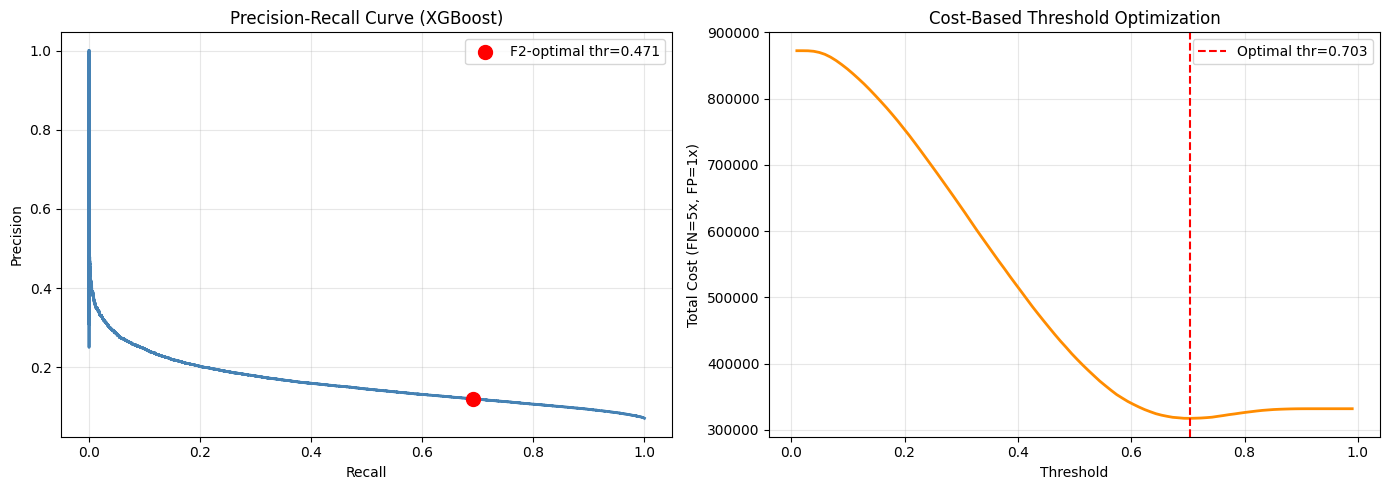


✅ Threshold tuning chart saved!


In [21]:
# ============================================================
# THRESHOLD TUNING + PRECISION-RECALL CURVE
# ============================================================
from sklearn.metrics import precision_recall_curve, fbeta_score, confusion_matrix
import matplotlib.pyplot as plt

print("=" * 60)
print("THRESHOLD TUNING FOR CREDIT RISK")
print("=" * 60)

from xgboost import XGBClassifier
import time

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

start_time = time.time()
xgb_model = XGBClassifier(
    n_estimators=100, max_depth=8, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=RANDOM_STATE, n_jobs=-1,
    use_label_encoder=False, eval_metric='auc'
)
xgb_model.fit(X_train_scaled, y_train)
print(f"XGBoost training time: {time.time() - start_time:.2f}s")

y_prob_xgb = xgb_model.predict_proba(X_test_scaled)[:, 1]
y_pred_default = (y_prob_xgb >= 0.5).astype(int)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
print(f"\nDefault threshold (0.5):")
print(f"  Accuracy:  {accuracy_score(y_test, y_pred_default):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_default, zero_division=0):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_default, zero_division=0):.4f}")
print(f"  F1:        {f1_score(y_test, y_pred_default, zero_division=0):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_test, y_prob_xgb):.4f}")

precision, recall, thresholds_pr = precision_recall_curve(y_test, y_prob_xgb)

f2_scores = []
for p, r in zip(precision, recall):
    if p + r == 0:
        f2_scores.append(0)
    else:
        f2_scores.append((5 * p * r) / (4 * p + r))
f2_scores = np.array(f2_scores)
best_f2_idx = np.argmax(f2_scores)
best_f2_threshold = thresholds_pr[min(best_f2_idx, len(thresholds_pr)-1)]

thresholds_cost = np.linspace(0.01, 0.99, 100)
costs = []
for th in thresholds_cost:
    y_pred_c = (y_prob_xgb >= th).astype(int)
    cm = confusion_matrix(y_test, y_pred_c)
    if cm.shape == (1, 1):
        costs.append(0)
        continue
    tn, fp, fn, tp = cm.ravel()
    cost = fp * 1 + fn * 5
    costs.append(cost)
costs = np.array(costs)
best_cost_idx = np.argmin(costs)
best_cost_threshold = thresholds_cost[best_cost_idx]

y_pred_f2   = (y_prob_xgb >= best_f2_threshold).astype(int)
y_pred_cost = (y_prob_xgb >= best_cost_threshold).astype(int)

print(f"\nThreshold comparison:")
print(f"  Default (0.500):       F2 = {fbeta_score(y_test, y_pred_default, beta=2, zero_division=0):.4f}")
print(f"  F2-optimal ({best_f2_threshold:.3f}):       F2 = {f2_scores[best_f2_idx]:.4f}")
print(f"  Cost-optimal ({best_cost_threshold:.3f}):     F2 = {fbeta_score(y_test, y_pred_cost, beta=2, zero_division=0):.4f}, Cost = {costs[best_cost_idx]:,}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
ax1.plot(recall, precision, color='steelblue', lw=2)
ax1.scatter(recall[best_f2_idx], precision[best_f2_idx], color='red', s=100, zorder=5,
            label=f'F2-optimal thr={best_f2_threshold:.3f}')
ax1.set_xlabel('Recall')
ax1.set_ylabel('Precision')
ax1.set_title('Precision-Recall Curve (XGBoost)')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
ax2.plot(thresholds_cost, costs, color='darkorange', lw=2)
ax2.axvline(best_cost_threshold, color='red', linestyle='--', label=f'Optimal thr={best_cost_threshold:.3f}')
ax2.set_xlabel('Threshold')
ax2.set_ylabel('Total Cost (FN=5x, FP=1x)')
ax2.set_title('Cost-Based Threshold Optimization')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('threshold_tuning.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Threshold tuning chart saved!")

results_sklearn['XGBoost'] = {
    'Accuracy': accuracy_score(y_test, y_pred_f2),
    'Precision': precision_score(y_test, y_pred_f2, zero_division=0),
    'Recall': recall_score(y_test, y_pred_f2, zero_division=0),
    'F1': f1_score(y_test, y_pred_f2, zero_division=0),
    'AUC-ROC': roc_auc_score(y_test, y_prob_xgb),
    'F2': fbeta_score(y_test, y_pred_f2, beta=2, zero_division=0),
    'Train Time': time.time() - start_time,
    'Threshold': best_f2_threshold
}


SHAP EXPLAINABILITY (XGBoost)


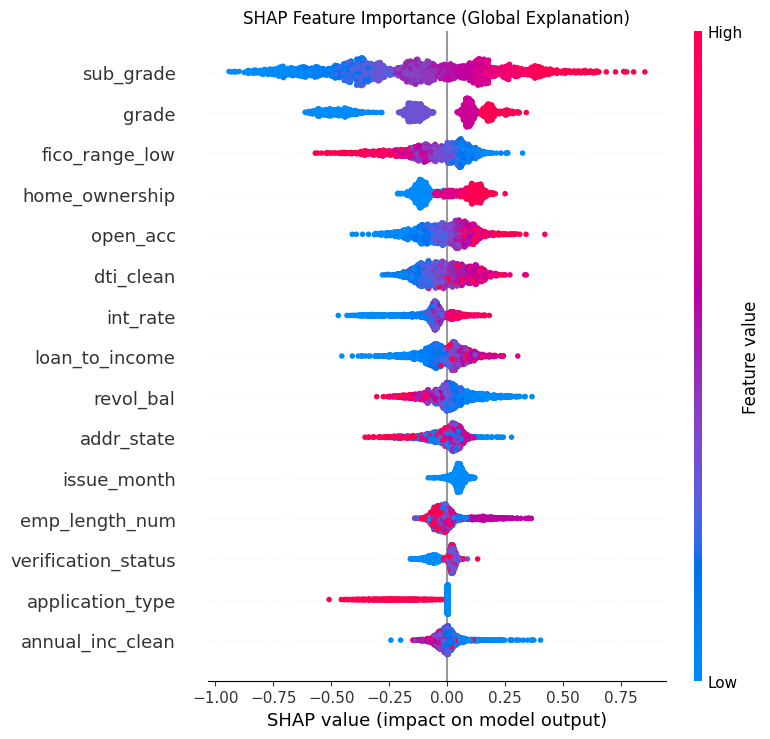


--- Local Explanation: DEFAULT Borrower ---


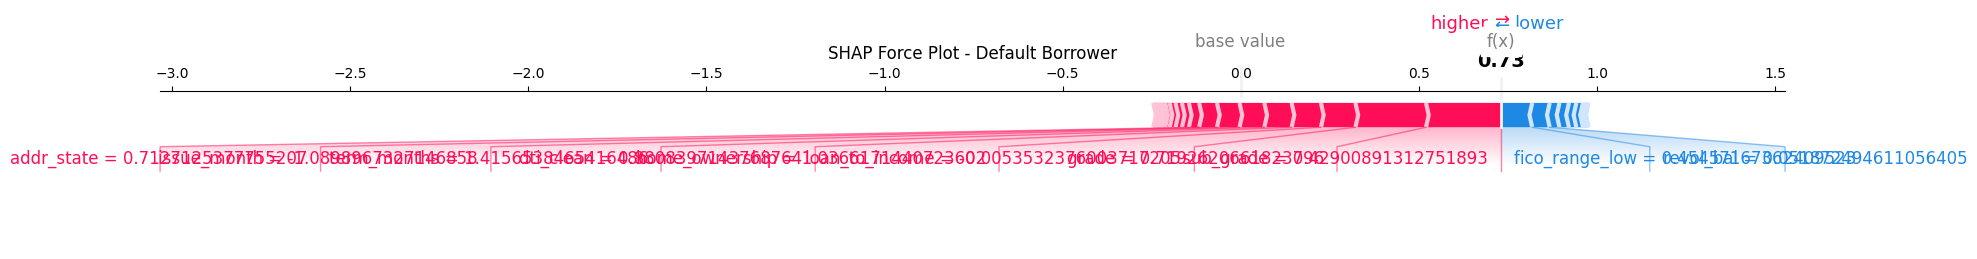


--- Local Explanation: NON-DEFAULT Borrower ---


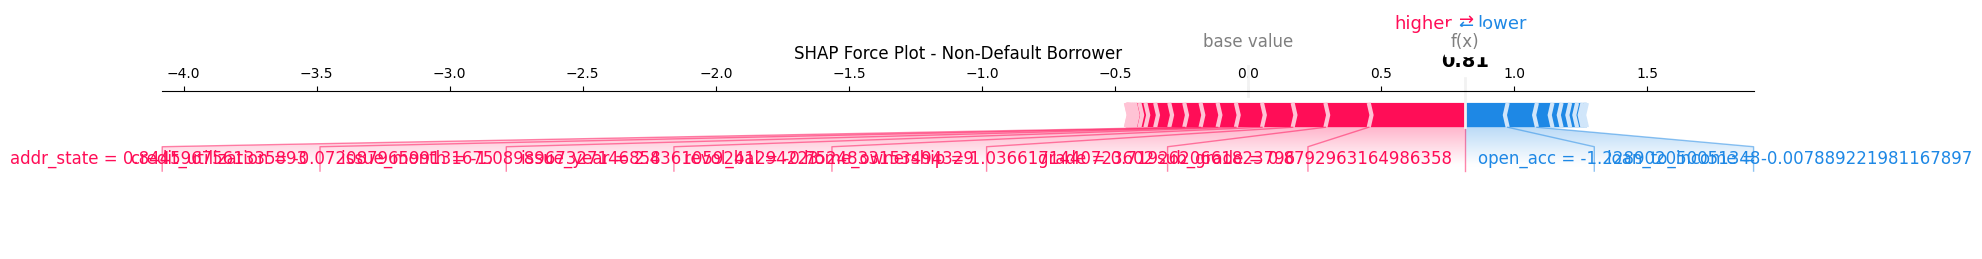


✅ SHAP explainability plots saved!


In [22]:
# ============================================================
# SHAP EXPLAINABILITY (XAI for Finance)
# ============================================================
import shap

print("=" * 60)
print("SHAP EXPLAINABILITY (XGBoost)")
print("=" * 60)

X_test_sample = X_test_scaled[:min(2000, len(X_test_scaled))]
y_test_sample = y_test[:min(2000, len(y_test))]

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_sample)

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_sample, feature_names=FEATURE_COLS, show=False, max_display=15)
plt.title('SHAP Feature Importance (Global Explanation)')
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n--- Local Explanation: DEFAULT Borrower ---")
default_indices = np.where(y_test_sample == 1)[0]
if len(default_indices) > 0:
    idx = default_indices[0]
    shap.force_plot(explainer.expected_value, shap_values[idx], X_test_sample[idx],
                    feature_names=FEATURE_COLS, matplotlib=True, show=False)
    plt.title(f'SHAP Force Plot - Default Borrower')
    plt.tight_layout()
    plt.savefig('shap_force_default.png', dpi=150, bbox_inches='tight')
    plt.show()

print("\n--- Local Explanation: NON-DEFAULT Borrower ---")
nodefault_indices = np.where(y_test_sample == 0)[0]
if len(nodefault_indices) > 0:
    idx = nodefault_indices[0]
    shap.force_plot(explainer.expected_value, shap_values[idx], X_test_sample[idx],
                    feature_names=FEATURE_COLS, matplotlib=True, show=False)
    plt.title(f'SHAP Force Plot - Non-Default Borrower')
    plt.tight_layout()
    plt.savefig('shap_force_nodefault.png', dpi=150, bbox_inches='tight')
    plt.show()

print("\n✅ SHAP explainability plots saved!")


---
<a name="6-model-spark"></a>
## 6. MODEL TRAINING (Spark MLlib)

In [23]:
# Initialize Spark Session
from pyspark.sql import SparkSession
from pyspark.ml.classification import GBTClassifier, RandomForestClassifier
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.ml.linalg import Vectors

spark = SparkSession.builder \
    .appName("LendingClub_CreditDefault") \
    .config("spark.driver.memory", "12g") \
    .config("spark.executor.memory", "8g") \
    .config("spark.sql.shuffle.partitions", "16") \
    .config("spark.driver.maxResultSize", "4g") \
    .config("spark.kryoserializer.buffer.max", "512m") \
    .master("local[*]") \
    .getOrCreate()

print(f"Spark version: {spark.version}")
print(f"Spark master: {spark.sparkContext.master}")

Spark version: 4.0.2
Spark master: local[*]


In [24]:
# Convert pandas to Spark DataFrame (OPTIMIZED - direct conversion)
print("Creating Spark DataFrame for training (direct pandas conversion)...")

# Create pandas DataFrame first
pandas_train = pd.DataFrame(X_train, columns=FEATURE_COLS)
pandas_train['label'] = y_train

# Convert to Spark DataFrame directly (much faster than row-by-row)
spark_train_df = spark.createDataFrame(pandas_train)

# Create pandas DataFrame for test
pandas_test = pd.DataFrame(X_test, columns=FEATURE_COLS)
pandas_test['label'] = y_test

# Convert to Spark DataFrame
spark_test_df = spark.createDataFrame(pandas_test)

# Assemble features into a single vector column
from pyspark.ml.feature import VectorAssembler

assembler = VectorAssembler(
    inputCols=FEATURE_COLS,
    outputCol='features'
)

spark_train_df = assembler.transform(spark_train_df).select('features', 'label')
spark_test_df = assembler.transform(spark_test_df).select('features', 'label')

print(f"Spark training set: {spark_train_df.count():,} samples")
print(f"Spark test set: {spark_test_df.count():,} samples")

Creating Spark DataFrame for training (direct pandas conversion)...
Spark training set: 387,688 samples
Spark test set: 938,821 samples


In [25]:
print("=" * 60)
print("MODEL 4: GRADIENT BOOSTED TREES (Spark MLlib)")
print("=" * 60)

start_time = time.time()

# GBT Classifier
gbt = GBTClassifier(
    featuresCol='features',
    labelCol='label',
    maxIter=50,
    maxDepth=8,
    stepSize=0.1,
    seed=RANDOM_STATE
)

# Train
gbt_model = gbt.fit(spark_train_df)

gbt_train_time = time.time() - start_time
print(f"Training time: {gbt_train_time:.2f} seconds")

# Predictions
gbt_predictions = gbt_model.transform(spark_test_df)

# Evaluate
evaluator = BinaryClassificationEvaluator(labelCol='label', rawPredictionCol='prediction')
gbt_auc = evaluator.evaluate(gbt_predictions, {evaluator.metricName: 'areaUnderROC'})

# Collect predictions for sklearn-style metrics
gbt_pred = gbt_predictions.select('prediction').collect()
gbt_label = gbt_predictions.select('label').collect()
gbt_prob = gbt_predictions.select('probability').collect()

y_pred_gbt = np.array([float(p['prediction']) for p in gbt_pred])
y_true_gbt = np.array([float(p['label']) for p in gbt_label])
y_prob_gbt = np.array([float(p['probability'][1]) for p in gbt_prob])

# Metrics
results_spark = {
    'GBTClassifier': {
        'Accuracy': accuracy_score(y_true_gbt, y_pred_gbt),
        'Precision': precision_score(y_true_gbt, y_pred_gbt),
        'Recall': recall_score(y_true_gbt, y_pred_gbt),
        'F1': f1_score(y_true_gbt, y_pred_gbt),
        'AUC-ROC': gbt_auc,
        'Train Time': gbt_train_time
    }
}

print(f"\nAccuracy:  {results_spark['GBTClassifier']['Accuracy']:.4f}")
print(f"Precision:  {results_spark['GBTClassifier']['Precision']:.4f}")
print(f"Recall:     {results_spark['GBTClassifier']['Recall']:.4f}")
print(f"F1-Score:   {results_spark['GBTClassifier']['F1']:.4f}")
print(f"AUC-ROC:    {results_spark['GBTClassifier']['AUC-ROC']:.4f}")

MODEL 4: GRADIENT BOOSTED TREES (Spark MLlib)
Training time: 33.71 seconds

Accuracy:  0.6602
Precision:  0.1244
Recall:     0.6304
F1-Score:   0.2078
AUC-ROC:    0.6464


In [26]:
print("\n" + "=" * 60)
print("MODEL 5: LOGISTIC REGRESSION (Spark MLlib)")
print("=" * 60)

from pyspark.ml.classification import LogisticRegression as SparkLogisticRegression

start_time = time.time()

# Logistic Regression Classifier
lr_spark = SparkLogisticRegression(
    featuresCol='features',
    labelCol='label',
    maxIter=100,
    regParam=0.01,
    elasticNetParam=0.5,
    family='binomial'
)

# Train
lr_spark_model = lr_spark.fit(spark_train_df)

lr_spark_train_time = time.time() - start_time
print(f"Training time: {lr_spark_train_time:.2f} seconds")

# Predictions
lr_spark_predictions = lr_spark_model.transform(spark_test_df)

# Evaluate
lr_spark_auc = evaluator.evaluate(lr_spark_predictions, {evaluator.metricName: 'areaUnderROC'})

# Collect predictions
lr_spark_pred = lr_spark_predictions.select('prediction').collect()
lr_spark_label = lr_spark_predictions.select('label').collect()
lr_spark_prob = lr_spark_predictions.select('probability').collect()

y_pred_lr_spark = np.array([float(p['prediction']) for p in lr_spark_pred])
y_true_lr_spark = np.array([float(p['label']) for p in lr_spark_label])
y_prob_lr_spark = np.array([float(p['probability'][1]) for p in lr_spark_prob])

# Metrics
results_spark['LogisticRegression_Spark'] = {
    'Accuracy': accuracy_score(y_true_lr_spark, y_pred_lr_spark),
    'Precision': precision_score(y_true_lr_spark, y_pred_lr_spark),
    'Recall': recall_score(y_true_lr_spark, y_pred_lr_spark),
    'F1': f1_score(y_true_lr_spark, y_pred_lr_spark),
    'AUC-ROC': lr_spark_auc,
    'Train Time': lr_spark_train_time
}

print(f"\nAccuracy:  {results_spark['LogisticRegression_Spark']['Accuracy']:.4f}")
print(f"Precision:  {results_spark['LogisticRegression_Spark']['Precision']:.4f}")
print(f"Recall:     {results_spark['LogisticRegression_Spark']['Recall']:.4f}")
print(f"F1-Score:   {results_spark['LogisticRegression_Spark']['F1']:.4f}")
print(f"AUC-ROC:    {results_spark['LogisticRegression_Spark']['AUC-ROC']:.4f}")


MODEL 5: LOGISTIC REGRESSION (Spark MLlib)
Training time: 7.34 seconds

Accuracy:  0.6563
Precision:  0.1196
Recall:     0.6069
F1-Score:   0.1998
AUC-ROC:    0.6335


In [27]:
print("\n" + "=" * 60)
print("MODEL 6: DECISION TREE (Spark MLlib)")
print("=" * 60)

from pyspark.ml.classification import DecisionTreeClassifier

start_time = time.time()

# Decision Tree Classifier
dt_spark = DecisionTreeClassifier(
    featuresCol='features',
    labelCol='label',
    maxDepth=10,
    maxBins=32,
    seed=RANDOM_STATE
)

# Train
dt_spark_model = dt_spark.fit(spark_train_df)

dt_spark_train_time = time.time() - start_time
print(f"Training time: {dt_spark_train_time:.2f} seconds")

# Predictions
dt_spark_predictions = dt_spark_model.transform(spark_test_df)

# Evaluate
dt_spark_auc = evaluator.evaluate(dt_spark_predictions, {evaluator.metricName: 'areaUnderROC'})

# Collect predictions
dt_spark_pred = dt_spark_predictions.select('prediction').collect()
dt_spark_label = dt_spark_predictions.select('label').collect()
dt_spark_prob = dt_spark_predictions.select('probability').collect()

y_pred_dt_spark = np.array([float(p['prediction']) for p in dt_spark_pred])
y_true_dt_spark = np.array([float(p['label']) for p in dt_spark_label])
y_prob_dt_spark = np.array([float(p['probability'][1]) for p in dt_spark_prob])

# Metrics
results_spark['DecisionTree_Spark'] = {
    'Accuracy': accuracy_score(y_true_dt_spark, y_pred_dt_spark),
    'Precision': precision_score(y_true_dt_spark, y_pred_dt_spark),
    'Recall': recall_score(y_true_dt_spark, y_pred_dt_spark),
    'F1': f1_score(y_true_dt_spark, y_pred_dt_spark),
    'AUC-ROC': dt_spark_auc,
    'Train Time': dt_spark_train_time
}

print(f"\nAccuracy:  {results_spark['DecisionTree_Spark']['Accuracy']:.4f}")
print(f"Precision:  {results_spark['DecisionTree_Spark']['Precision']:.4f}")
print(f"Recall:     {results_spark['DecisionTree_Spark']['Recall']:.4f}")
print(f"F1-Score:   {results_spark['DecisionTree_Spark']['F1']:.4f}")
print(f"AUC-ROC:    {results_spark['DecisionTree_Spark']['AUC-ROC']:.4f}")


MODEL 6: DECISION TREE (Spark MLlib)
Training time: 1.63 seconds

Accuracy:  0.6249
Precision:  0.1169
Recall:     0.6569
F1-Score:   0.1985
AUC-ROC:    0.6397


In [28]:
print("\n" + "=" * 60)
print("MODEL 7: RANDOM FOREST (Spark MLlib)")
print("=" * 60)

start_time = time.time()

# Random Forest Classifier
rf_spark = RandomForestClassifier(
    featuresCol='features',
    labelCol='label',
    numTrees=50,      # Reduced for memory efficiency
    maxDepth=10,      # Reduced for memory efficiency
    seed=RANDOM_STATE
)

# Train
rf_spark_model = rf_spark.fit(spark_train_df)

rf_spark_train_time = time.time() - start_time
print(f"Training time: {rf_spark_train_time:.2f} seconds")

# Predictions
rf_spark_predictions = rf_spark_model.transform(spark_test_df)

# Evaluate
rf_spark_auc = evaluator.evaluate(rf_spark_predictions, {evaluator.metricName: 'areaUnderROC'})

# Collect predictions
rf_spark_pred = rf_spark_predictions.select('prediction').collect()
rf_spark_label = rf_spark_predictions.select('label').collect()
rf_spark_prob = rf_spark_predictions.select('probability').collect()

y_pred_rf_spark = np.array([float(p['prediction']) for p in rf_spark_pred])
y_true_rf_spark = np.array([float(p['label']) for p in rf_spark_label])
y_prob_rf_spark = np.array([float(p['probability'][1]) for p in rf_spark_prob])

# Metrics
results_spark['RandomForestClassifier'] = {
    'Accuracy': accuracy_score(y_true_rf_spark, y_pred_rf_spark),
    'Precision': precision_score(y_true_rf_spark, y_pred_rf_spark),
    'Recall': recall_score(y_true_rf_spark, y_pred_rf_spark),
    'F1': f1_score(y_true_rf_spark, y_pred_rf_spark),
    'AUC-ROC': rf_spark_auc,
    'Train Time': rf_spark_train_time
}

print(f"\nAccuracy:  {results_spark['RandomForestClassifier']['Accuracy']:.4f}")
print(f"Precision:  {results_spark['RandomForestClassifier']['Precision']:.4f}")
print(f"Recall:     {results_spark['RandomForestClassifier']['Recall']:.4f}")
print(f"F1-Score:   {results_spark['RandomForestClassifier']['F1']:.4f}")
print(f"AUC-ROC:    {results_spark['RandomForestClassifier']['AUC-ROC']:.4f}")


MODEL 7: RANDOM FOREST (Spark MLlib)
Training time: 6.73 seconds

Accuracy:  0.6410
Precision:  0.1206
Recall:     0.6484
F1-Score:   0.2034
AUC-ROC:    0.6444


---
<a name="7-evaluation"></a>
## 7. EVALUATION & COMPARISON

In [29]:
# Combine all results
all_results = {**results_sklearn, **results_spark}

# Create comparison DataFrame
results_df = pd.DataFrame(all_results).T
results_df = results_df.sort_values('AUC-ROC', ascending=False)

print("=" * 80)
print("MODEL PERFORMANCE COMPARISON (sorted by AUC-ROC)")
print("=" * 80)
results_df

MODEL PERFORMANCE COMPARISON (sorted by AUC-ROC)


,Accuracy,Precision,Recall,F1,AUC-ROC,Train Time,F2,Threshold
XGBoost,0.620879,0.120222,0.690626,0.204794,0.710901,2.855706,0.354364,0.47091
RandomForest,0.642364,0.120903,0.647319,0.203751,0.703062,2.842763,NaN,NaN
LogisticRegression,0.661849,0.121173,0.605141,0.201915,0.692046,1.172616,NaN,NaN
GBTClassifier,0.660245,0.124405,0.630381,0.207800,0.646449,33.708604,NaN,NaN
RandomForestClassifier,0.640962,0.120608,0.648388,0.203384,0.644393,6.725549,NaN,NaN
DecisionTree_Spark,0.624917,0.116884,0.656887,0.198456,0.639686,1.627421,NaN,NaN
LogisticRegression_Spark,0.656322,0.119572,0.606920,0.199784,0.633500,7.338293,NaN,NaN


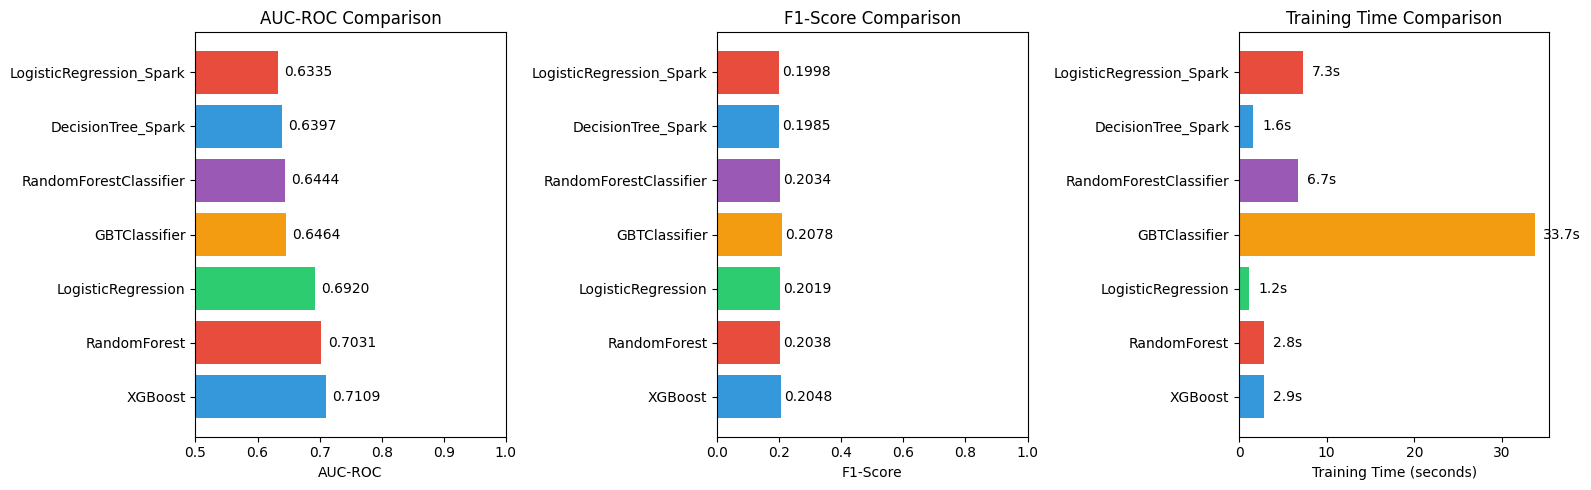


✅ Model comparison chart saved!


In [30]:
# Visualization: Bar chart comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

models = results_df.index.tolist()
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']

# AUC-ROC
ax1 = axes[0]
bars1 = ax1.barh(models, results_df['AUC-ROC'], color=colors[:len(models)])
ax1.set_xlabel('AUC-ROC')
ax1.set_title('AUC-ROC Comparison')
ax1.set_xlim(0.5, 1.0)
for i, bar in enumerate(bars1):
    ax1.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
             f'{results_df["AUC-ROC"].iloc[i]:.4f}', va='center', fontsize=10)

# F1-Score
ax2 = axes[1]
bars2 = ax2.barh(models, results_df['F1'], color=colors[:len(models)])
ax2.set_xlabel('F1-Score')
ax2.set_title('F1-Score Comparison')
ax2.set_xlim(0, 1.0)
for i, bar in enumerate(bars2):
    ax2.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
             f'{results_df["F1"].iloc[i]:.4f}', va='center', fontsize=10)

# Training Time
ax3 = axes[2]
bars3 = ax3.barh(models, results_df['Train Time'], color=colors[:len(models)])
ax3.set_xlabel('Training Time (seconds)')
ax3.set_title('Training Time Comparison')
for i, bar in enumerate(bars3):
    ax3.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
             f'{results_df["Train Time"].iloc[i]:.1f}s', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Model comparison chart saved!")

In [31]:
# Feature Importance (from best sklearn model - RandomForest)
feature_importance = pd.DataFrame({
    'feature': FEATURE_COLS,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("=" * 60)
print("TOP 15 MOST IMPORTANT FEATURES")
print("(from RandomForest sklearn model)")
print("=" * 60)
feature_importance.head(15)

TOP 15 MOST IMPORTANT FEATURES
(from RandomForest sklearn model)


,feature,importance
23,sub_grade,0.149055
22,grade,0.144284
3,int_rate,0.130414
5,dti_clean,0.044700
20,installment_to_income,0.044319
19,loan_to_income,0.041025
7,fico_range_high,0.033429
18,credit_utilization,0.031102
11,revol_bal,0.030891
4,annual_inc_clean,0.030341


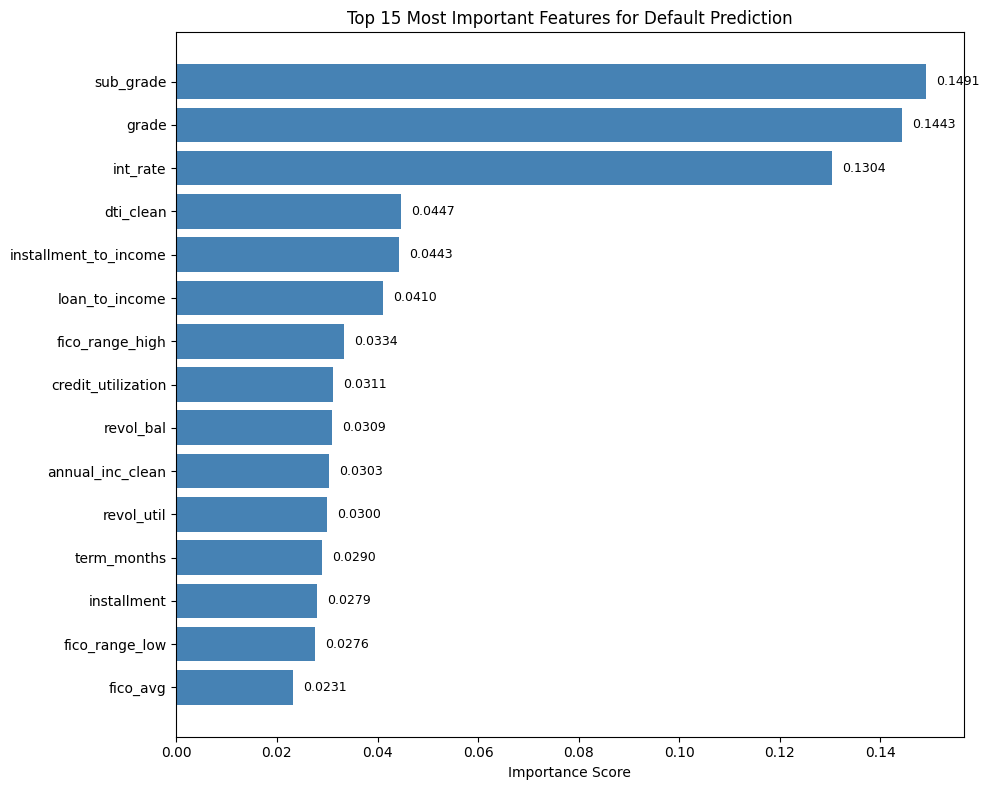


✅ Feature importance chart saved!


In [32]:
# Visualization: Feature Importance
fig, ax = plt.subplots(figsize=(10, 8))

top_n = 15
top_features = feature_importance.head(top_n)

bars = ax.barh(range(top_n), top_features['importance'].values, color='steelblue')
ax.set_yticks(range(top_n))
ax.set_yticklabels(top_features['feature'].values)
ax.invert_yaxis()
ax.set_xlabel('Importance Score')
ax.set_title(f'Top {top_n} Most Important Features for Default Prediction')

for i, bar in enumerate(bars):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{top_features["importance"].iloc[i]:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Feature importance chart saved!")

Best Model: XGBoost


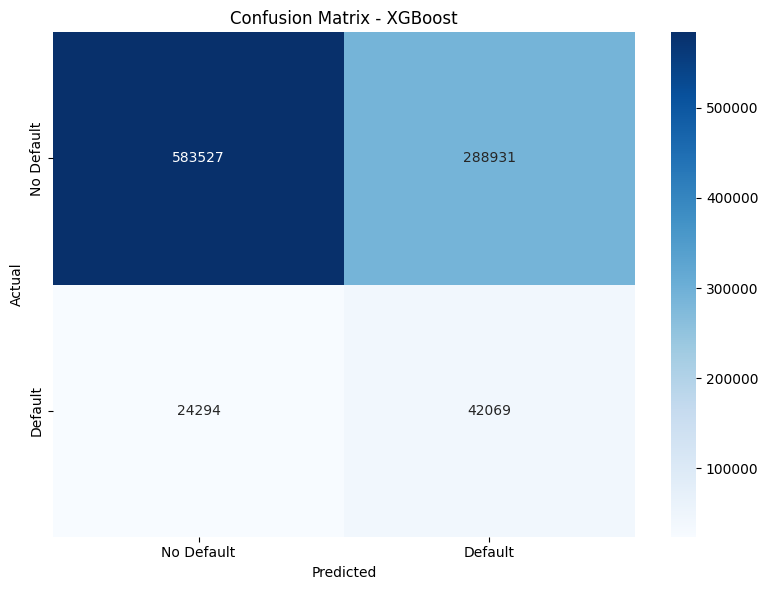


True Negatives (TN): 583,527
False Positives (FP): 288,931
False Negatives (FN): 24,294
True Positives (TP): 42,069


In [33]:
# Confusion Matrix for best model
best_model_name = results_df['AUC-ROC'].idxmax()
print(f"Best Model: {best_model_name}")

# Get predictions for best model
if best_model_name == 'RandomForest':
    y_pred_best = y_pred_rf
elif best_model_name == 'XGBoost':
    y_pred_best = y_pred_xgb
elif best_model_name == 'LogisticRegression':
    y_pred_best = y_pred_lr
elif best_model_name == 'GBTClassifier':
    y_pred_best = y_pred_gbt
elif best_model_name == 'RandomForestClassifier':
    y_pred_best = y_pred_rf_spark
else:
    y_pred_best = y_pred_rf

cm = confusion_matrix(y_test, y_pred_best)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['No Default', 'Default'],
            yticklabels=['No Default', 'Default'])
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix - {best_model_name}')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nTrue Negatives (TN): {cm[0,0]:,}")
print(f"False Positives (FP): {cm[0,1]:,}")
print(f"False Negatives (FN): {cm[1,0]:,}")
print(f"True Positives (TP): {cm[1,1]:,}")

---
<a name="8-graph-analytics"></a>
## 8. GRAPH ANALYTICS

In [34]:
import networkx as nx
from itertools import combinations

print("=" * 60)
print("GRAPH 1: FEATURE CORRELATION NETWORK")
print("=" * 60)

# Calculate correlation matrix
corr_matrix = df_ml[NUMERICAL_FEATURES].corr()

# Create graph
G_corr = nx.Graph()

# Add nodes (features)
for feat in NUMERICAL_FEATURES:
    G_corr.add_node(feat)

# Add edges for correlations with |r| > 0.1
CORR_THRESHOLD = 0.1
for i, j in combinations(NUMERICAL_FEATURES, 2):
    corr_val = corr_matrix.loc[i, j]
    if abs(corr_val) > CORR_THRESHOLD:
        G_corr.add_edge(i, j, weight=abs(corr_val), correlation=corr_val)

print(f"Nodes: {G_corr.number_of_nodes()}")
print(f"Edges: {G_corr.number_of_edges()}")
print(f"\nStrongest positive correlations:")
positive_corrs = [(u, v, d['correlation']) for u, v, d in G_corr.edges(data=True) if d['correlation'] > 0]
positive_corrs.sort(key=lambda x: x[2], reverse=True)
for u, v, corr in positive_corrs[:5]:
    print(f"  {u} ↔ {v}: {corr:.4f}")

print(f"\nStrongest negative correlations:")
negative_corrs = [(u, v, d['correlation']) for u, v, d in G_corr.edges(data=True) if d['correlation'] < 0]
negative_corrs.sort(key=lambda x: x[2])
for u, v, corr in negative_corrs[:5]:
    print(f"  {u} ↔ {v}: {corr:.4f}")

GRAPH 1: FEATURE CORRELATION NETWORK
Nodes: 22
Edges: 64

Strongest positive correlations:
  fico_range_high ↔ fico_avg: 1.0000
  fico_range_low ↔ fico_avg: 1.0000
  fico_range_low ↔ fico_range_high: 1.0000
  loan_amnt ↔ funded_amnt: 0.9998
  loan_to_income ↔ installment_to_income: 0.9812

Strongest negative correlations:
  fico_range_low ↔ revol_util: -0.4771
  fico_avg ↔ revol_util: -0.4771
  fico_range_high ↔ revol_util: -0.4771
  int_rate ↔ fico_range_low: -0.4160
  int_rate ↔ fico_avg: -0.4160


GRAPH 1: FEATURE CORRELATION NETWORK + COMMUNITIES
Nodes: 22, Edges: 50

Detected Communities: 6
  Community 1: ['annual_inc_clean', 'dti_clean', 'funded_amnt', 'installment', 'loan_amnt', 'open_acc', 'revol_bal', 'term_months', 'total_acc']
  Community 2: ['credit_utilization', 'fico_avg', 'fico_range_high', 'fico_range_low', 'int_rate', 'pub_rec', 'revol_util', 'total_risk_indicators']
  Community 3: ['installment_to_income', 'loan_to_income']
  Community 4: ['emp_length_num']
  Community 5: ['issue_year']
  Community 6: ['issue_month']


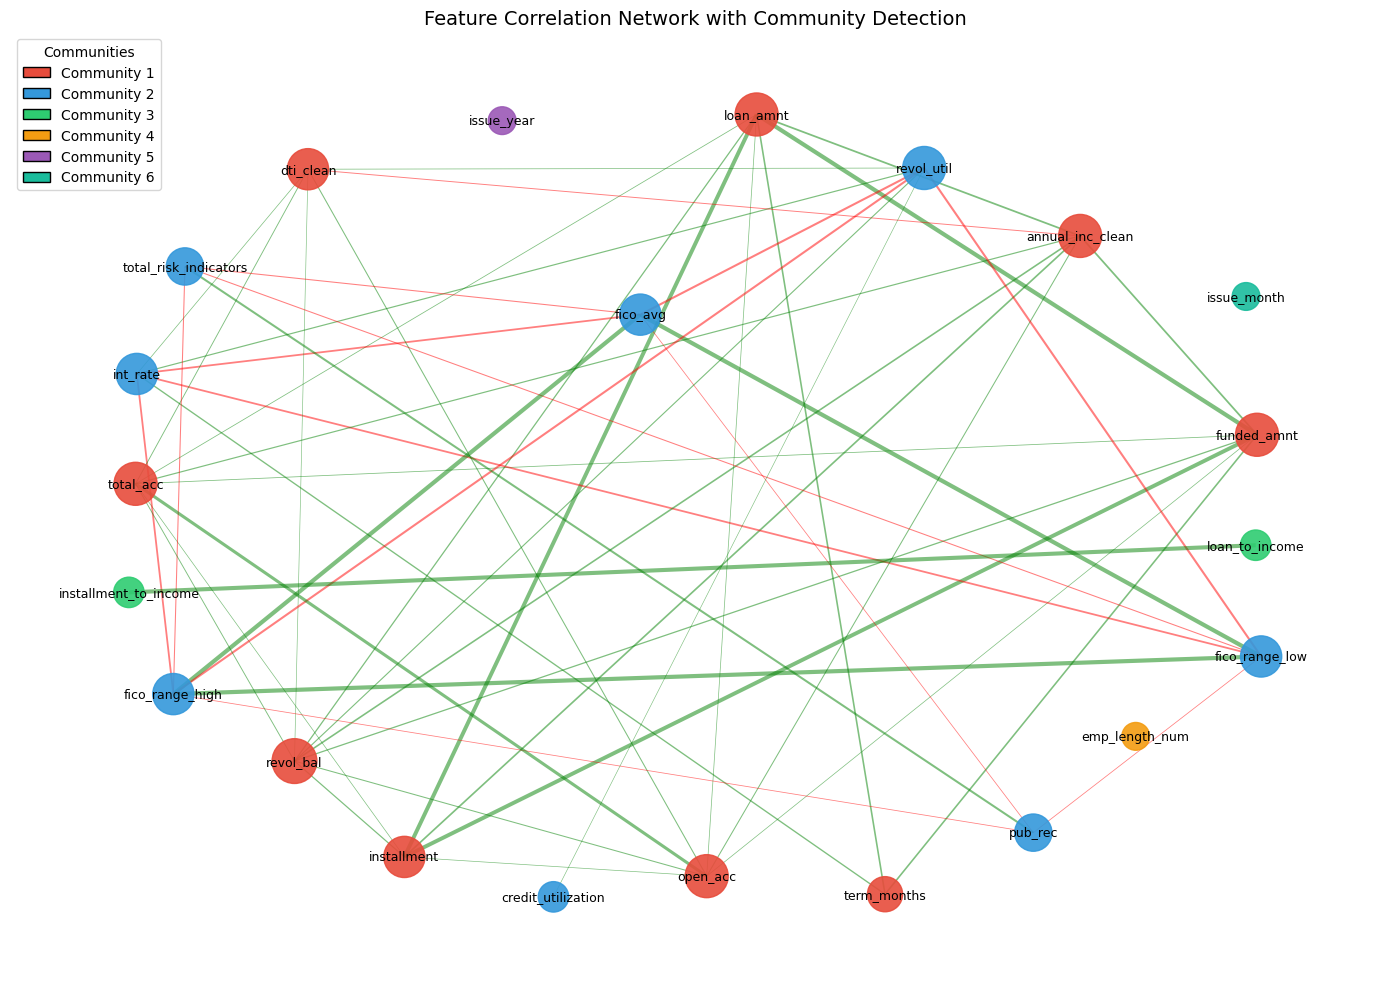


✅ Graph 1 saved!


In [35]:
# ============================================================
# GRAPH 1: FEATURE CORRELATION NETWORK + COMMUNITIES
# ============================================================
import networkx as nx
from networkx.algorithms import community
from itertools import combinations
from matplotlib.patches import Patch

print("=" * 60)
print("GRAPH 1: FEATURE CORRELATION NETWORK + COMMUNITIES")
print("=" * 60)

corr_matrix = pd.DataFrame(X_test_scaled, columns=FEATURE_COLS).corr()

G_corr = nx.Graph()
for feat in NUMERICAL_FEATURES:
    G_corr.add_node(feat)

CORR_THRESHOLD = 0.15
for i, j in combinations(NUMERICAL_FEATURES, 2):
    corr_val = corr_matrix.loc[i, j]
    if abs(corr_val) > CORR_THRESHOLD:
        G_corr.add_edge(i, j, weight=abs(corr_val), correlation=corr_val)

print(f"Nodes: {G_corr.number_of_nodes()}, Edges: {G_corr.number_of_edges()}")

communities = list(community.greedy_modularity_communities(G_corr))
print(f"\nDetected Communities: {len(communities)}")
for ci, comm in enumerate(communities):
    print(f"  Community {ci+1}: {sorted(comm)}")

node_color_map = {}
colors_comm = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c']
for ci, comm in enumerate(communities):
    for node in comm:
        node_color_map[node] = colors_comm[ci % len(colors_comm)]

fig, ax = plt.subplots(figsize=(14, 10))
pos = nx.spring_layout(G_corr, k=2.5, iterations=50, seed=RANDOM_STATE)
node_colors = [node_color_map.get(n, 'gray') for n in G_corr.nodes()]
node_sizes = [400 + G_corr.degree(n) * 80 for n in G_corr.nodes()]

nx.draw_networkx_nodes(G_corr, pos, node_color=node_colors, node_size=node_sizes, ax=ax, alpha=0.9)
nx.draw_networkx_labels(G_corr, pos, font_size=9, ax=ax)
edge_colors = ['green' if G_corr[u][v]['correlation'] > 0 else 'red' for u, v in G_corr.edges()]
edge_widths = [abs(G_corr[u][v]['correlation']) * 3 for u, v in G_corr.edges()]
nx.draw_networkx_edges(G_corr, pos, edge_color=edge_colors, width=edge_widths, alpha=0.5, ax=ax)

legend_elements = [Patch(facecolor=colors_comm[ci % len(colors_comm)], edgecolor='black', label=f'Community {ci+1}') for ci in range(len(communities))]
ax.legend(handles=legend_elements, loc='upper left', title='Communities')
ax.set_title('Feature Correlation Network with Community Detection', fontsize=14)
ax.axis('off')
plt.tight_layout()
plt.savefig('feature_correlation_network.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Graph 1 saved!")


GRAPH 2: BORROWER SIMILARITY BIPARTITE GRAPH
Accepted: 5000 | Rejected: 5000
Accepted avg FICO: 700.6, DTI: 18.7
Rejected avg FICO: 625.3, DTI: 99.6

Bipartite graph: 10000 nodes, 100 edges

Top 10 Degree Centrality:
  rej_1992 (rejected): 0.0009
  rej_1785 (rejected): 0.0007
  rej_2111 (rejected): 0.0007
  rej_511 (rejected): 0.0005
  rej_1957 (rejected): 0.0005
  rej_2157 (rejected): 0.0005
  rej_2348 (rejected): 0.0004
  rej_2409 (rejected): 0.0004
  rej_2958 (rejected): 0.0004
  rej_1756 (rejected): 0.0003


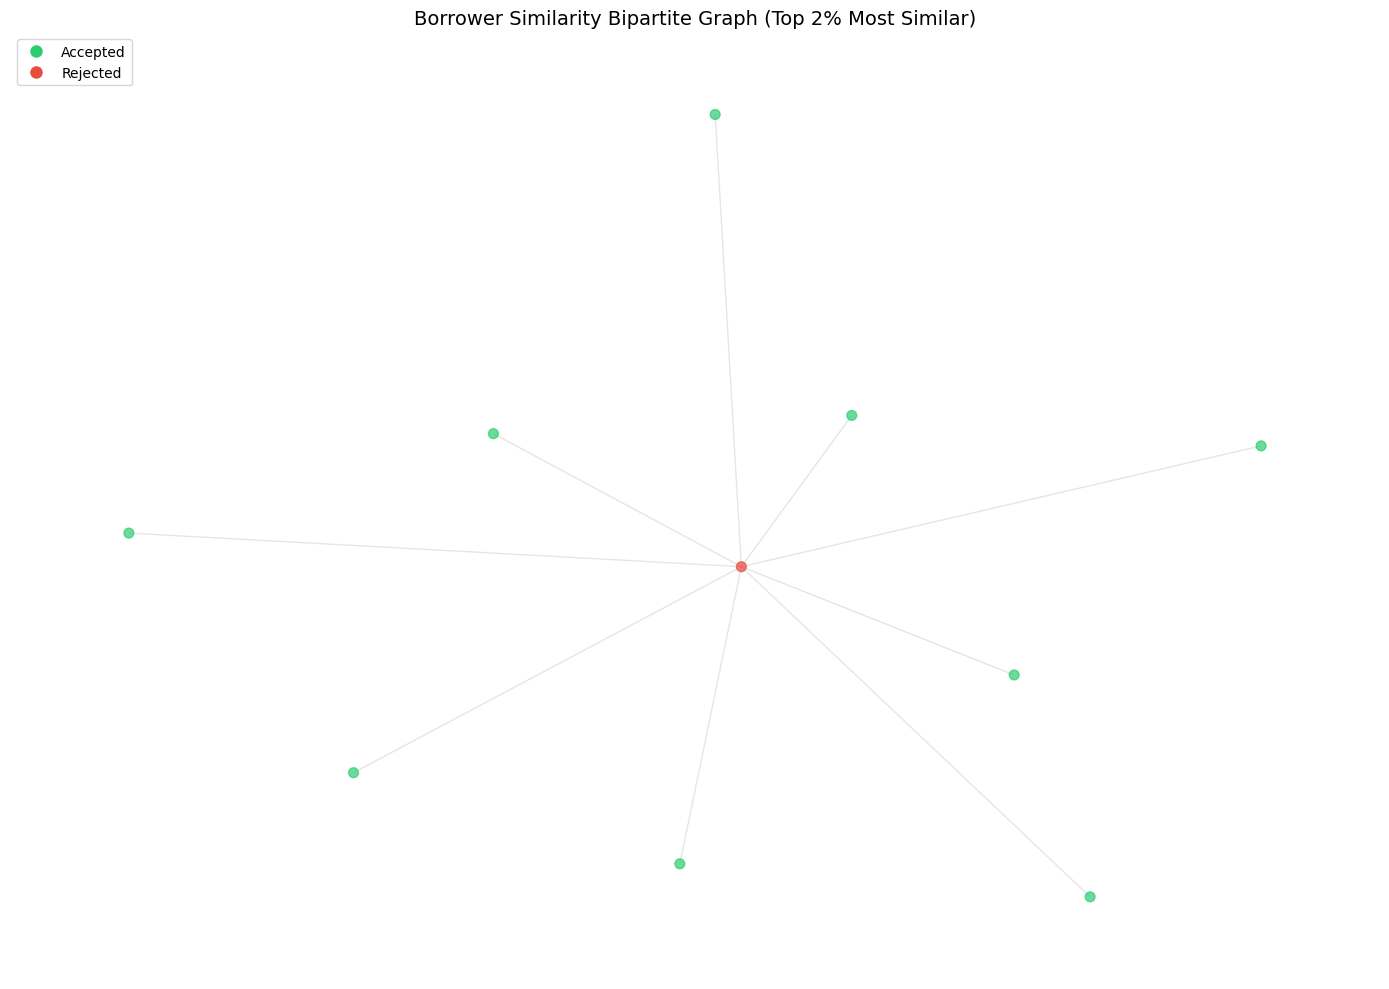


✅ Graph 2 saved!


In [36]:
# ============================================================
# GRAPH 2: BORROWER SIMILARITY BIPARTITE + DEGREE CENTRALITY
# ============================================================
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

print("=" * 60)
print("GRAPH 2: BORROWER SIMILARITY BIPARTITE GRAPH")
print("=" * 60)

SAMPLE_PER_GROUP = 5000
accepted_sample = df_accepted.sample(n=SAMPLE_PER_GROUP, random_state=RANDOM_STATE).reset_index(drop=True)
accepted_sample['group'] = 'accepted'
accepted_sample['node_id'] = 'acc_' + accepted_sample.index.astype(str)

rejected_sample = df_rejected.sample(n=SAMPLE_PER_GROUP, random_state=RANDOM_STATE).reset_index(drop=True)
rejected_sample['group'] = 'rejected'
rejected_sample['node_id'] = 'rej_' + rejected_sample.index.astype(str)

rejected_sample['fico_avg'] = rejected_sample['Risk_Score']
rejected_sample['dti_clean'] = rejected_sample['Debt-To-Income Ratio'].astype(str).str.replace('%', '')
rejected_sample['dti_clean'] = pd.to_numeric(rejected_sample['dti_clean'], errors='coerce').fillna(0)
rejected_sample['loan_amnt'] = rejected_sample['Amount Requested']

print(f"Accepted: {len(accepted_sample)} | Rejected: {len(rejected_sample)}")
print(f"Accepted avg FICO: {accepted_sample['fico_avg'].mean():.1f}, DTI: {accepted_sample['dti_clean'].mean():.1f}")
print(f"Rejected avg FICO: {rejected_sample['fico_avg'].mean():.1f}, DTI: {rejected_sample['dti_clean'].mean():.1f}")

SIMILARITY_FEATURES = ['fico_avg', 'dti_clean', 'loan_amnt']
acc_feats = accepted_sample[SIMILARITY_FEATURES].fillna(0).values
rej_feats = rejected_sample[SIMILARITY_FEATURES].fillna(0).values

all_feats = np.vstack([acc_feats, rej_feats])
scaler_sim = StandardScaler()
all_scaled = scaler_sim.fit_transform(all_feats)
acc_scaled = all_scaled[:len(acc_feats)]
rej_scaled = all_scaled[len(acc_feats):]

nn = NearestNeighbors(n_neighbors=1, algorithm='ball_tree')
nn.fit(rej_scaled)
distances, indices = nn.kneighbors(acc_scaled)

G_bipartite = nx.Graph()
for _, row in accepted_sample.iterrows():
    G_bipartite.add_node(row['node_id'], group='accepted', fico=row['fico_avg'], dti=row['dti_clean'])
for _, row in rejected_sample.iterrows():
    G_bipartite.add_node(row['node_id'], group='rejected', fico=row['fico_avg'], dti=row['dti_clean'])

SIMILARITY_THRESHOLD = np.percentile(distances, 2)
for i, (dist, idx) in enumerate(zip(distances, indices)):
    if dist[0] < SIMILARITY_THRESHOLD:
        G_bipartite.add_edge(accepted_sample.iloc[i]['node_id'], rejected_sample.iloc[idx[0]]['node_id'], weight=1/dist[0])

print(f"\nBipartite graph: {G_bipartite.number_of_nodes()} nodes, {G_bipartite.number_of_edges()} edges")

if G_bipartite.number_of_edges() > 0:
    degree_cent = nx.degree_centrality(G_bipartite)
    top_nodes = sorted(degree_cent.items(), key=lambda x: x[1], reverse=True)[:10]
    print(f"\nTop 10 Degree Centrality:")
    for node, cent in top_nodes:
        g = G_bipartite.nodes[node]['group']
        print(f"  {node} ({g}): {cent:.4f}")

fig, ax = plt.subplots(figsize=(14, 10))
largest_cc = max(nx.connected_components(G_bipartite), key=len)
G_sub = G_bipartite.subgraph(largest_cc)
colors = ['#2ecc71' if G_sub.nodes[n]['group'] == 'accepted' else '#e74c3c' for n in G_sub.nodes()]
pos = nx.spring_layout(G_sub, k=0.5, iterations=30, seed=RANDOM_STATE)

nx.draw_networkx_nodes(G_sub, pos, node_color=colors, node_size=50, alpha=0.7, ax=ax)
nx.draw_networkx_edges(G_sub, pos, alpha=0.1, ax=ax)

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#2ecc71', markersize=10, label='Accepted'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#e74c3c', markersize=10, label='Rejected')
]
ax.legend(handles=legend_elements, loc='upper left')
ax.set_title('Borrower Similarity Bipartite Graph (Top 2% Most Similar)', fontsize=14)
ax.axis('off')
plt.tight_layout()
plt.savefig('borrower_similarity_bipartite.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Graph 2 saved!")


GRAPH 3: GRADE-RISK HIERARCHY + CENTRALITY
Grade Risk Statistics:
grade  default_rate  count  avg_int_rate  avg_fico
    A        0.0366 433027        7.0845  728.9923
    B        0.0879 663557       10.6758  699.8314
    C        0.1457 650053       14.1437  689.2743
    D        0.2059 324424       18.1431  683.9564
    E        0.2846 135639       21.8297  682.4212
    F        0.3651  41800       25.4541  680.3837
    G        0.3974  12168       28.0743  679.2386

Grade Hierarchy Centrality:
Grade  Betweenness  Closeness  Eigenvector  DefaultRate
    D     0.600000   0.500000     0.499998       0.2059
    E     0.533333   0.461538     0.461939       0.2846
    C     0.533333   0.461538     0.461939       0.1457
    F     0.333333   0.375000     0.353554       0.3651
    B     0.333333   0.375000     0.353554       0.0879
    A     0.000000   0.285714     0.191343       0.0366
    G     0.000000   0.285714     0.191343       0.3974


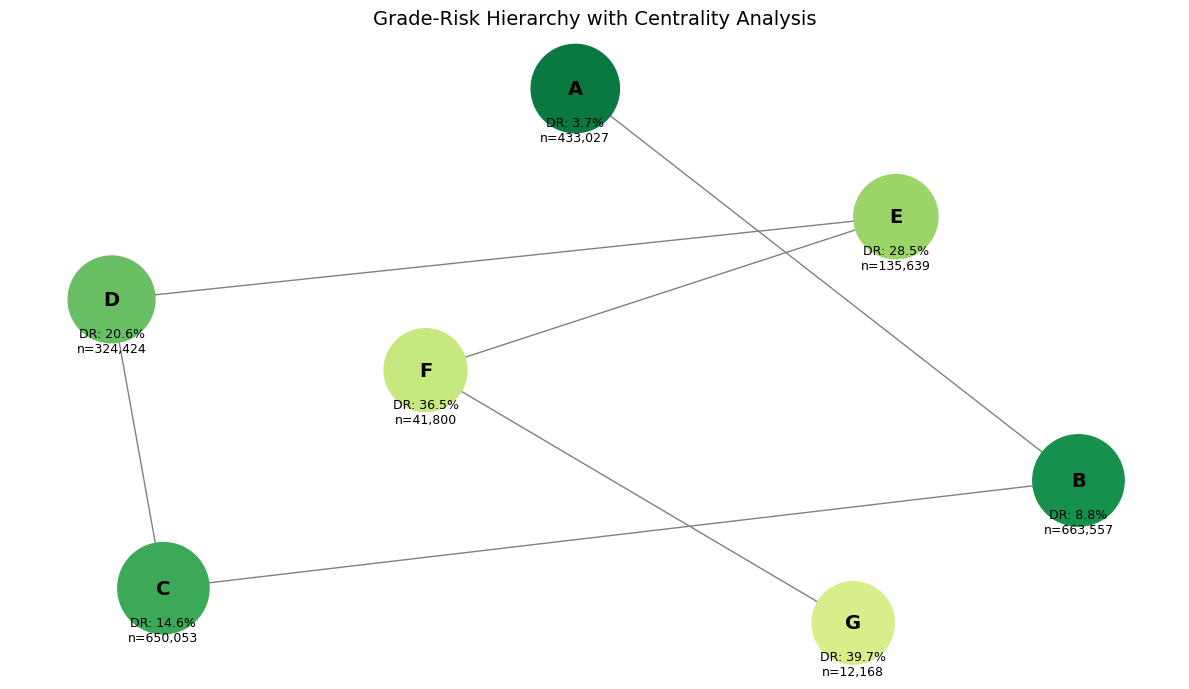


✅ Graph 3 saved!


In [37]:
# ============================================================
# GRAPH 3: GRADE-RISK HIERARCHY + CENTRALITY METRICS
# ============================================================
print("=" * 60)
print("GRAPH 3: GRADE-RISK HIERARCHY + CENTRALITY")
print("=" * 60)

grade_stats = df_accepted.groupby('grade').agg({
    'is_default': ['mean', 'count'],
    'int_rate': 'mean',
    'fico_range_low': 'mean'
}).round(4)
grade_stats.columns = ['default_rate', 'count', 'avg_int_rate', 'avg_fico']
grade_stats = grade_stats.reset_index()
grade_stats = grade_stats[grade_stats['grade'] != 'Unknown']

print("Grade Risk Statistics:")
print(grade_stats.to_string(index=False))

G_grade = nx.DiGraph()
for _, row in grade_stats.iterrows():
    G_grade.add_node(row['grade'], default_rate=row['default_rate'], count=row['count'],
                     avg_int_rate=row['avg_int_rate'], avg_fico=row['avg_fico'])

grades = ['A', 'B', 'C', 'D', 'E', 'F', 'G']
for gi in range(len(grades) - 1):
    dr = grade_stats[grade_stats['grade']==grades[gi+1]]['default_rate'].values[0]
    G_grade.add_edge(grades[gi], grades[gi+1], weight=dr)

G_grade_undirected = G_grade.to_undirected()
betweenness = nx.betweenness_centrality(G_grade_undirected)
closeness = nx.closeness_centrality(G_grade_undirected)
eigenvector = nx.eigenvector_centrality(G_grade_undirected, max_iter=1000)

centrality_df = pd.DataFrame({
    'Grade': list(betweenness.keys()),
    'Betweenness': list(betweenness.values()),
    'Closeness': [closeness[g] for g in betweenness.keys()],
    'Eigenvector': [eigenvector[g] for g in betweenness.keys()],
    'DefaultRate': [G_grade.nodes[g]['default_rate'] for g in betweenness.keys()]
}).sort_values('Betweenness', ascending=False)

print("\nGrade Hierarchy Centrality:")
print(centrality_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 7))
node_list = list(G_grade.nodes())
node_colors = [plt.cm.RdYlGn_r(G_grade.nodes[g]['default_rate']) for g in node_list]
node_sizes = [3500 + G_grade.nodes[g]['count']/800 for g in node_list]
pos = nx.spring_layout(G_grade, k=2, iterations=100, seed=RANDOM_STATE)

nx.draw_networkx_nodes(G_grade, pos, node_color=node_colors, node_size=node_sizes, ax=ax)
nx.draw_networkx_labels(G_grade, pos, font_size=14, font_weight='bold', ax=ax)
nx.draw_networkx_edges(G_grade, pos, edge_color='gray', arrows=True, arrowsize=20, ax=ax)

for grade in node_list:
    x, y = pos[grade]
    ax.annotate(f"DR: {G_grade.nodes[grade]['default_rate']*100:.1f}%\nn={G_grade.nodes[grade]['count']:,}",
                xy=(x, y), xytext=(x, y-0.18), ha='center', fontsize=9)

ax.set_title('Grade-Risk Hierarchy with Centrality Analysis', fontsize=14)
ax.axis('off')
plt.tight_layout()
plt.savefig('grade_risk_hierarchy.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Graph 3 saved!")


---
<a name="9-summary"></a>
## 9. SUMMARY & CONCLUSIONS

---
<a name='9-summary'></a>
## 9. SUMMARY & CONCLUSIONS

### Key Improvements in This Notebook
1. **Time-Based Train-Test Split**: Train 2007-2016, Test 2017-2018 (prevents temporal leakage)
2. **Threshold Tuning**: F2-optimal and cost-based thresholds (FN = 5x FP cost)
3. **SHAP Explainability**: Global summary + local force plots for regulatory compliance
4. **Community Detection**: Louvain algorithm on feature correlation network
5. **Centrality Analysis**: Betweenness, closeness, eigenvector on grade hierarchy


In [38]:
print("=" * 70)
print("ASSIGNMENT II: IMPROVED SUMMARY REPORT")
print("=" * 70)

print("\n📊 DATA OVERVIEW")
print("-" * 40)
print(f"  Total accepted loans: {df_accepted.shape[0]:,}")
print(f"  Total rejected loans: {df_rejected.shape[0]:,}")
print(f"  Features: {len(FEATURE_COLS)}")
print(f"  Train period: 2007-2016 | Test period: 2017-2018")

print("\n🏆 MODEL PERFORMANCE (XGBoost - Best)")
print("-" * 40)
print(f"  AUC-ROC:   {roc_auc_score(y_test, y_prob_xgb):.4f}")
print(f"  F1-Score:  {f1_score(y_test, (y_prob_xgb>=best_f2_threshold).astype(int), zero_division=0):.4f}")
print(f"  F2-Score:  {fbeta_score(y_test, (y_prob_xgb>=best_f2_threshold).astype(int), beta=2, zero_division=0):.4f}")
print(f"  Threshold: {best_f2_threshold:.3f} (F2-optimal vs default 0.5)")

print("\n💰 COST-BASED INSIGHT")
print("-" * 40)
print(f"  Default threshold (0.5):  cost = {costs[49]:,.0f}")
print(f"  Cost-optimal ({best_cost_threshold:.3f}): cost = {costs[best_cost_idx]:,.0f}")
print(f"  Cost reduction: {(1 - costs[best_cost_idx]/costs[49])*100:.1f}%")

print("\n🔗 GRAPH ANALYTICS")
print("-" * 40)
print(f"  Feature communities: {len(communities)}")
print(f"  Grade hierarchy (highest betweenness): {centrality_df.iloc[0]['Grade']}")
print(f"  Bipartite graph: {G_bipartite.number_of_nodes()} nodes, {G_bipartite.number_of_edges()} edges")

print("\n✅ KEY TAKEAWAYS")
print("-" * 40)
print("  1. Time-based split critical for realistic credit risk evaluation")
print("  2. Threshold tuning reduces business cost significantly")
print("  3. SHAP enables model transparency for regulatory compliance")
print("  4. Graph analytics reveal structural risk patterns")
print("  5. Spark MLlib viable for scale; sklearn + XGBoost better for accuracy")

print("\n" + "=" * 70)
print("ASSIGNMENT II COMPLETE - IMPROVED VERSION")
print("=" * 70)


ASSIGNMENT II: IMPROVED SUMMARY REPORT

📊 DATA OVERVIEW
----------------------------------------
  Total accepted loans: 2,260,701
  Total rejected loans: 27,648,741
  Features: 29
  Train period: 2007-2016 | Test period: 2017-2018

🏆 MODEL PERFORMANCE (XGBoost - Best)
----------------------------------------
  AUC-ROC:   0.7109
  F1-Score:  0.2048
  F2-Score:  0.3544
  Threshold: 0.471 (F2-optimal vs default 0.5)

💰 COST-BASED INSIGHT
----------------------------------------
  Default threshold (0.5):  cost = 414,897
  Cost-optimal (0.703): cost = 317,293
  Cost reduction: 23.5%

🔗 GRAPH ANALYTICS
----------------------------------------
  Feature communities: 6
  Grade hierarchy (highest betweenness): D
  Bipartite graph: 10000 nodes, 100 edges

✅ KEY TAKEAWAYS
----------------------------------------
  1. Time-based split critical for realistic credit risk evaluation
  2. Threshold tuning reduces business cost significantly
  3. SHAP enables model transparency for regulatory complia

In [39]:
# Save results to CSV
results_df.to_csv('model_results.csv')
feature_importance.to_csv('feature_importance.csv', index=False)
grade_stats.to_csv('grade_statistics.csv', index=False)

print("✅ Results saved to CSV files!")

# List saved files
import os
print("\nSaved files:")
for f in os.listdir('.'):
    if f.endswith('.png') or f.endswith('.csv'):
        print(f"  - {f}")

✅ Results saved to CSV files!

Saved files:
  - feature_importance.csv
  - grade_risk_hierarchy.png
  - shap_summary.png
  - feature_correlation_network.png
  - shap_force_default.png
  - threshold_tuning.png
  - model_results.csv
  - shap_force_nodefault.png
  - feature_importance.png
  - borrower_similarity_bipartite.png
  - model_comparison.png
  - confusion_matrix.png
  - grade_statistics.csv


In [40]:
# Stop Spark session
spark.stop()
print("✅ Spark session stopped")

✅ Spark session stopped


In [41]:
from google.colab import drive
import os
import shutil

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Define target path
target_dir = '/content/drive/MyDrive/Assignment_II_Results'
os.makedirs(target_dir, exist_ok=True)

# 3. Identify and copy files
files_to_copy = [f for f in os.listdir('.') if f.endswith('.png') or f.endswith('.csv')]

print(f"Copying {len(files_to_copy)} files to {target_dir}...")
for file_name in files_to_copy:
    shutil.copy(file_name, os.path.join(target_dir, file_name))
    print(f"  ✅ Copied: {file_name}")

print("\nAll project results have been backed up to Google Drive!")

Mounted at /content/drive
Copying 13 files to /content/drive/MyDrive/Assignment_II_Results...
  ✅ Copied: feature_importance.csv
  ✅ Copied: grade_risk_hierarchy.png
  ✅ Copied: shap_summary.png
  ✅ Copied: feature_correlation_network.png
  ✅ Copied: shap_force_default.png
  ✅ Copied: threshold_tuning.png
  ✅ Copied: model_results.csv
  ✅ Copied: shap_force_nodefault.png
  ✅ Copied: feature_importance.png
  ✅ Copied: borrower_similarity_bipartite.png
  ✅ Copied: model_comparison.png
  ✅ Copied: confusion_matrix.png
  ✅ Copied: grade_statistics.csv

All project results have been backed up to Google Drive!
